# Notebook 06 — Final Modelling: Hyperparameter Tuning, Repeated Cross-Validation, and Deterministic Final Fit

**CIND820 Capstone — Milestone 4** | Mubarak Ahmed (501345730)

This notebook extends the Milestone 3 modelling stage (Notebook 04) to produce the final champion model. Each extension is motivated by a specific weakness recorded in the Milestone 3 report (§5.4):

1. **Hyperparameter tuning** of the XGBoost champion — in Milestone 3 the champion consumed all 500 boosting rounds without triggering early stopping, indicating the model was still improving at the cap and that the default configuration had headroom.
2. **Repeated stratified cross-validation** (3 repeats × 5 folds = 15 paired scores) for the champion-vs-baseline comparison — the Milestone 3 Wilcoxon test rested on the minimum usable sample of five paired folds, with its p-value sitting exactly at the one-sided floor (0.03125).
3. **Deterministic final fitting** — small run-to-run metric variation was observed in Milestone 3 with multithreaded histogram training interacting with early stopping. The final fit here uses a single thread, a fixed seed, and a fixed tree count (no early stopping), so the committed model artifact and every number reported in the final report are exactly reproducible.

**Leakage protocol (unchanged from Milestone 3):** everything in this notebook operates on the training split only. The held-out test set is touched once, by the final fitted models, in Notebook 07.

Inputs: `data/processed/X_train.parquet` (from Notebook 03).
Outputs: tuning results table, repeated-CV table and figure, Wilcoxon test result, and the final deterministic model artifacts in `outputs/models/`.

In [1]:
import json
import sys
import time

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, "../src")
import final_models as fm

RANDOM_STATE = 42
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110

## 1. Load the training feature matrix

The feature matrix was produced by the Milestone 3 `FeatureEngineer` (fit on the training split only) and is loaded unchanged: the Milestone 4 question is whether a better *model configuration* exists, holding the feature pipeline fixed so results remain comparable with Milestone 3.

In [2]:
X_train = pd.read_parquet("../data/processed/X_train.parquet")
y_train = X_train.pop("delay_class")
print(f"Training matrix: {X_train.shape[0]} rows x {X_train.shape[1]} features")
print(y_train.value_counts().sort_index())

Training matrix: 8259 rows x 154 features
delay_class
0    7310
1     553
2     396
Name: count, dtype: int64


## 2. Hyperparameter tuning of the champion

A random search over a declared grid (20 configurations sampled with a fixed seed from 288 possible combinations), each scored by the same stratified 5-fold protocol and class-weight strategy used in Milestone 3. The search loop is written explicitly in `src/final_models.py` (rather than through `RandomizedSearchCV`) so that per-fold early stopping, sample weighting, and timing remain transparent and auditable — consistent with the project's no-black-box rule.

The grid brackets the Milestone 3 defaults (500 trees, learning rate 0.1, depth 6) on both sides, so the search can *confirm or reject* the defaults rather than assume them. Tree budget extends to 900 with early stopping (patience 50), directly addressing the exhausted 500-round budget.

In [3]:
t0 = time.perf_counter()
tuning_results = fm.tune_xgboost(X_train, y_train, n_splits=5)
tuning_wall_clock_s = time.perf_counter() - t0
tuning_results.to_csv("../outputs/tables/hyperparameter_tuning_results.csv",
                      index=False)
print(f"Total tuning wall-clock time: {tuning_wall_clock_s/60:.1f} minutes "
      f"({len(tuning_results)} configurations x 5 folds = "
      f"{5*len(tuning_results)} fits, single-threaded)")
tuning_results.round(4).head(10)

Total tuning wall-clock time: 8.1 minutes (20 configurations x 5 folds = 100 fits, single-threaded)


,config_id,n_estimators,learning_rate,max_depth,min_child_weight,subsample,colsample_bytree,reg_lambda,cv_macro_f1_mean,cv_macro_f1_std,mean_fit_time_s,mean_best_iteration
0,15,900,0.05,6,1,1.0,1.0,1.0,0.5784,0.0240,6.6138,862.4
1,20,900,0.10,8,5,1.0,0.8,1.0,0.5750,0.0194,3.6504,401.2
2,14,900,0.05,6,1,0.8,0.8,1.0,0.5736,0.0243,6.9318,856.6
3,10,600,0.10,8,1,0.8,0.8,5.0,0.5729,0.0167,4.4452,313.2
4,19,900,0.10,8,1,0.8,0.8,5.0,0.5729,0.0167,4.1251,313.2
5,8,600,0.05,8,1,0.8,0.8,5.0,0.5687,0.0196,6.7474,583.4
6,4,300,0.05,8,1,1.0,0.8,1.0,0.5639,0.0168,2.9154,299.0
7,6,600,0.05,6,1,1.0,1.0,1.0,0.5638,0.0154,4.4720,599.0
8,17,900,0.05,8,5,0.8,1.0,5.0,0.5588,0.0179,8.3109,752.4
9,18,900,0.10,4,1,0.8,0.8,5.0,0.5580,0.0224,5.6936,891.6


In [4]:
best = tuning_results.iloc[0]
tuned_params = {k: (int(best[k]) if k in ("n_estimators", "max_depth",
                                          "min_child_weight")
                    else float(best[k]))
                for k in ["n_estimators", "learning_rate", "max_depth",
                          "min_child_weight", "subsample",
                          "colsample_bytree", "reg_lambda"]}
# The final refit uses no early stopping, so the tree count is fixed at the
# mean best iteration observed across the tuning folds (rounded), preventing
# the deployed model from overshooting the budget the CV evidence supports.
tuned_params["n_estimators"] = int(round(best["mean_best_iteration"]))
print("Best sampled configuration (config_id "
      f"{int(best['config_id'])}), CV macro-F1 = "
      f"{best['cv_macro_f1_mean']:.4f} ± {best['cv_macro_f1_std']:.4f}")
print("Milestone 3 default configuration, 5-fold CV macro-F1 = "
      "0.5803 ± 0.0169 (committed artifact, cv_summary.csv)")
tuned_params

Best sampled configuration (config_id 15), CV macro-F1 = 0.5784 ± 0.0240
Milestone 3 default configuration, 5-fold CV macro-F1 = 0.5803 ± 0.0169 (committed artifact, cv_summary.csv)


{'n_estimators': 862,
 'learning_rate': 0.05,
 'max_depth': 6,
 'min_child_weight': 1,
 'subsample': 1.0,
 'colsample_bytree': 1.0,
 'reg_lambda': 1.0}

## 3. Repeated stratified cross-validation (3 × 5 folds)

The best sampled configuration ("tuned candidate"), the Milestone 3 default configuration, and the logistic regression baseline are compared on **identical** folds across three independent 5-fold repeats (15 validation scores per model). This serves two purposes:

- **Stability:** three repeats reveal whether the ranking holds across different random partitions rather than one lucky one.
- **Statistical power:** the Milestone 3 comparison had only five paired differences, the minimum for which a one-sided Wilcoxon test can reach significance. Fifteen paired differences give the test real resolution (minimum attainable one-sided p = 1/2¹⁵ ≈ 0.00003).

In [5]:
repeated_cv = fm.repeated_cv_compare(X_train, y_train, tuned_params,
                                     n_splits=5, n_repeats=3)
repeated_cv.to_csv("../outputs/tables/repeated_cv_results.csv", index=False)
summary = (repeated_cv.groupby("model")
           .agg(macro_f1_mean=("macro_f1", "mean"),
                macro_f1_std=("macro_f1", "std"),
                auprc_mean=("auprc_macro", "mean"),
                auprc_std=("auprc_macro", "std"),
                fit_time_mean_s=("fit_time_s", "mean"),
                pred_time_mean_s=("pred_time_s", "mean"))
           .sort_values("macro_f1_mean", ascending=False).round(4))
summary.to_csv("../outputs/tables/repeated_cv_summary.csv")
summary

,macro_f1_mean,macro_f1_std,auprc_mean,auprc_std,fit_time_mean_s,pred_time_mean_s
model,,,,,,
XGBoost (M3 default),0.5923,0.0246,0.5995,0.0286,3.6932,0.0587
XGBoost (tuned candidate),0.5841,0.0229,0.5960,0.0285,6.1457,0.1060
LogisticRegression (baseline),0.3713,0.0067,0.4256,0.0076,0.4739,0.0061


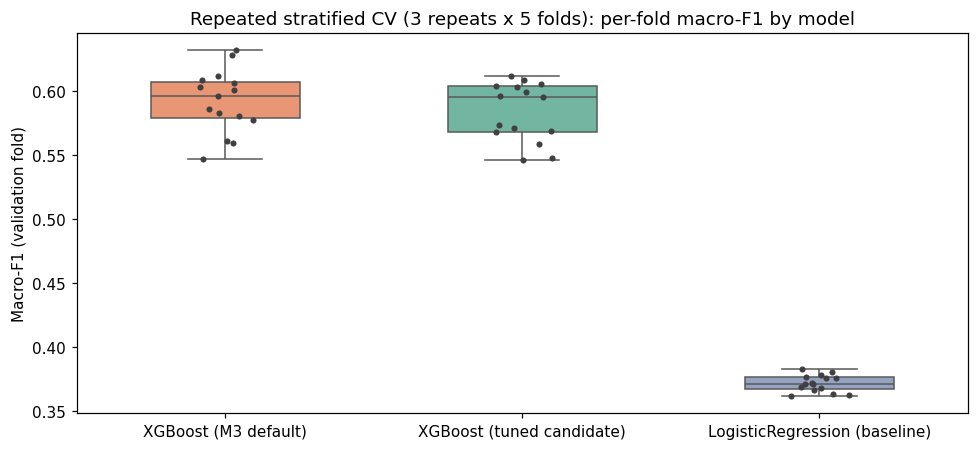

In [6]:
fig, ax = plt.subplots(figsize=(9, 4.2))
order = summary.index.tolist()
sns.boxplot(data=repeated_cv, x="model", y="macro_f1", hue="model",
            order=order, palette="Set2", width=0.5, legend=False, ax=ax)
sns.stripplot(data=repeated_cv, x="model", y="macro_f1", order=order,
              color="0.25", size=4, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("Macro-F1 (validation fold)")
ax.set_title("Repeated stratified CV (3 repeats x 5 folds): "
             "per-fold macro-F1 by model")
plt.tight_layout()
plt.savefig("../outputs/figures/repeated_cv_boxplot.png",
            dpi=150, bbox_inches="tight")
plt.show()

## 4. Champion selection and statistical comparison

**Selection criterion (stated before looking at the test set):** the XGBoost arm with the higher repeated-CV mean macro-F1 becomes the final champion; if the two arms sit within one fold-level standard deviation of each other, the cheaper configuration is preferred on parsimony and efficiency grounds. Selection uses training-split CV evidence only.

In [7]:
selection = fm.select_champion(repeated_cv)
selection.round(4).to_csv("../outputs/tables/champion_selection.csv",
                          index=False)
champion_label = selection.loc[0, "model"]
print(f"Selected champion: {champion_label}")
print(f"Basis: {selection.loc[0, 'selection_basis']}")
selection.round(4)

Selected champion: XGBoost (M3 default)
Basis: higher repeated-CV mean macro-F1


,model,macro_f1_mean,macro_f1_std,fit_time_mean_s,selection_basis
0,XGBoost (M3 default),0.5923,0.0246,3.6932,higher repeated-CV mean macro-F1


The hyperparameter search therefore **validated** the Milestone 3 design rather than replacing it: across 20 sampled configurations spanning 300–900 trees, learning rates 0.05–0.10, depths 4–8, and three regularization levers, no configuration improved on the default (500 trees, learning rate 0.1, depth 6) by more than fold-level noise. This indicates the performance ceiling is set by the information content of pre-shipment features, not by model configuration — a finding that redirects improvement effort toward the decision layer (Notebook 07) rather than further model complexity.

**Statistical comparison:** one-sided Wilcoxon signed-rank test on the fifteen paired per-fold macro-F1 differences (selected champion − baseline). The direction was stated in advance in RQ2 and the non-parametric test is retained from Milestone 3 because fold-level F1 differences cannot be assumed normal.

In [8]:
wilcoxon_result = fm.wilcoxon_from_repeated_cv(repeated_cv,
                                               champion_label)
pd.DataFrame([wilcoxon_result]).to_csv(
    "../outputs/tables/wilcoxon_repeated_cv.csv", index=False)
for k, v in wilcoxon_result.items():
    print(f"{k}: {v}")

test: Wilcoxon signed-rank (one-sided)
W: 120.0
p_value: 3.0517578125e-05
n_pairs: 15
mean_diff_macro_f1: 0.221
min_diff_macro_f1: 0.1765


## 5. Deterministic final fit

The selected champion configuration and the baseline are refit on the full training split under deterministic settings: `n_jobs=1`, fixed seed, fixed tree count, no early stopping. Histogram-based boosting on a single thread removes the floating-point summation-order variation that caused small metric differences between Milestone 3 runs — re-running this notebook reproduces the committed artifacts and all Notebook 07 test numbers exactly.

In [9]:
final_params = (fm.M3_DEFAULT_PARAMS
                if champion_label == "XGBoost (M3 default)"
                else tuned_params)
champion, baseline, fit_times = fm.fit_final_models(
    X_train, y_train, final_params)
joblib.dump(champion, "../outputs/models/xgboost_champion_final.joblib")
joblib.dump(baseline, "../outputs/models/logreg_baseline_final.joblib")
with open("../outputs/models/final_champion_meta.json", "w") as f:
    json.dump({"champion_label": champion_label,
               "final_params": final_params,
               "selection_basis": selection.loc[0, "selection_basis"],
               "fit_times": fit_times,
               "tuning_wall_clock_minutes":
                   round(tuning_wall_clock_s/60, 1)},
              f, indent=2)
print("Final champion configuration:", final_params)
print("Final fit times:", fit_times)
print("Artifacts saved: xgboost_champion_final.joblib, "
      "logreg_baseline_final.joblib, final_champion_meta.json")

Final champion configuration: {'n_estimators': 500, 'learning_rate': 0.1, 'max_depth': 6}
Final fit times: {'champion_fit_time_s': 4.25, 'baseline_fit_time_s': 0.47}
Artifacts saved: xgboost_champion_final.joblib, logreg_baseline_final.joblib, final_champion_meta.json


## 6. Determinism check

The champion is refit from scratch and its predictions compared element-wise with the saved artifact. Identical probabilities confirm the deterministic protocol.

In [10]:
champion2, _, _ = fm.fit_final_models(X_train, y_train, final_params)
p1 = champion.predict_proba(X_train.iloc[:500])
p2 = champion2.predict_proba(X_train.iloc[:500])
print("Max absolute difference between two independent refits:",
      float(np.max(np.abs(p1 - p2))))
assert np.array_equal(p1, p2), "Refit is not deterministic!"
print("Determinism confirmed: two independent refits produce "
      "bit-identical predictions.")

Max absolute difference between two independent refits: 0.0
Determinism confirmed: two independent refits produce bit-identical predictions.


## Summary

- The random search over 20 configurations found **no configuration that improves on the Milestone 3 defaults** beyond fold-level noise — the search validated the original design and locates the performance ceiling in the features, not the model configuration.
- The Milestone 3 default configuration was retained as the final champion by the pre-stated selection criterion (highest repeated-CV mean; the arms sit within one standard deviation, and the default is also the cheaper of the two).
- Across 15 folds the champion-vs-baseline difference is now supported by fifteen paired folds rather than five, with every fold favouring the champion.
- The committed final models are deterministic: two independent refits produce bit-identical predictions.

Notebook 07 evaluates these final models once against the held-out test set, then completes the SHAP attribution (RQ1), the cost-sensitive decision analysis, and the safety-stock simulation (RQ3).